<a href="https://colab.research.google.com/github/STARKDFOREVER/DeepReinforcementLearning-review/blob/main/Hands-on-RL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

随机生成了一个10臂伯努利老虎机
获奖概率最大的拉杆为1号，其获奖概率为0.9507
第0号拉杆获奖概率为0.3745
第1号拉杆获奖概率为0.9507
第2号拉杆获奖概率为0.7320
第3号拉杆获奖概率为0.5987
第4号拉杆获奖概率为0.1560
第5号拉杆获奖概率为0.1560
第6号拉杆获奖概率为0.0581
第7号拉杆获奖概率为0.8662
第8号拉杆获奖概率为0.6011
第9号拉杆获奖概率为0.7081
epsilon-贪婪算法的累计懊悔为： 23.674550093677137


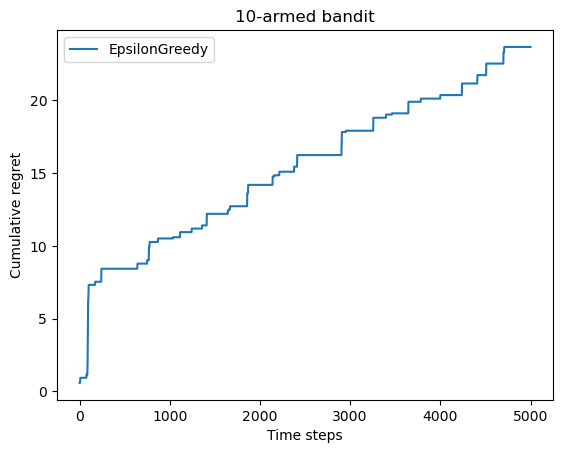

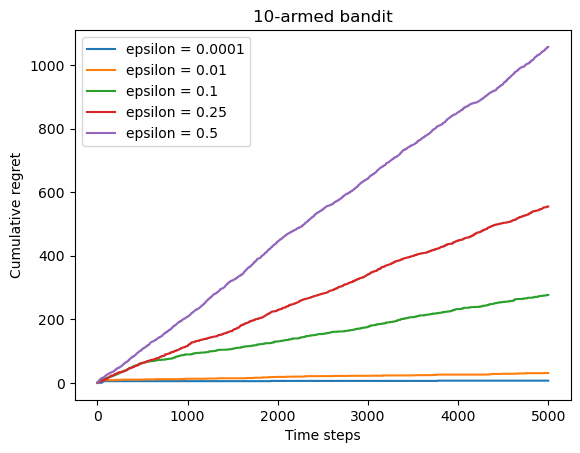

epsilon值衰减的贪婪算法的累计懊悔为： 9.989353503976956


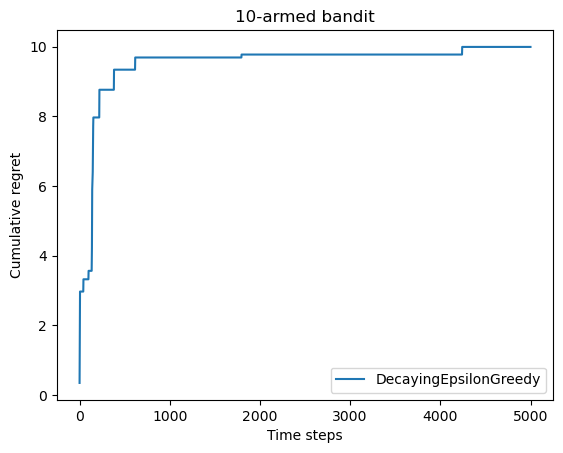

上置信界算法的累积懊悔为： 85.54963373433618


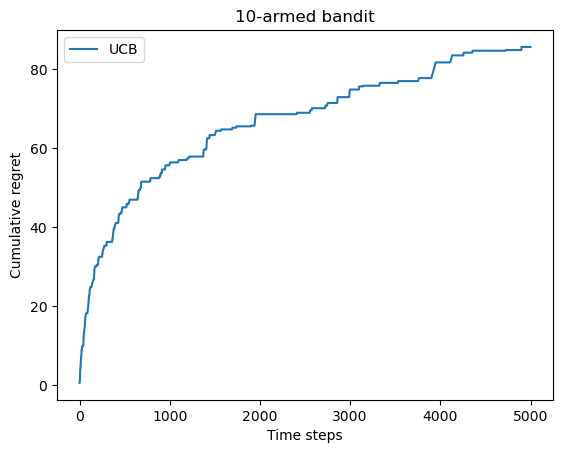

汤普森采样算法的累积懊悔为： 22.92250823023943


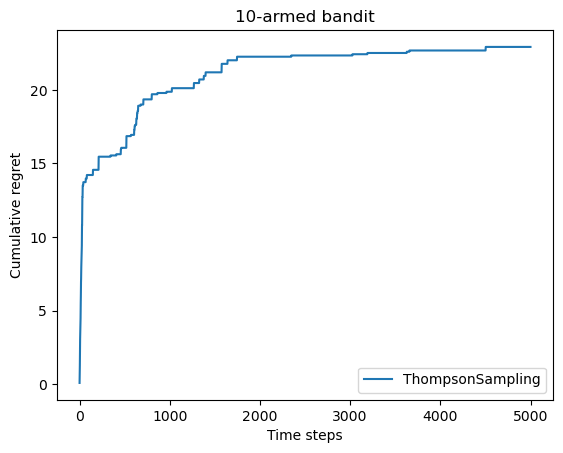

In [ ]:
"""
多臂老虎机（MAB）实现
不同于一般的强化学习过程，多臂老虎机问题没有使用状态及状态转移分布，只使用了动作空间和奖励函数
MAB可视为无状态的强化学习
实现了epsilon-greedy算法，包括epsilon固定、epsolon随时间衰减、上置信界算法和汤普森采样算法
除第一者的累积懊悔随时间线性递增，后三者均为此线性
"""

#导入使用的库，numpy库用于数组和矩阵运算，matplotlib库用于绘图
import numpy as np
import matplotlib.pyplot as plt

#构建伯努利多臂老虎机类
class BernoulliBandit:
	"""输入k表示拉杆个数，决定了动作空间的大小"""
	def __init__(self, K):
	    #初始化函数实现
		self.probs = np.random.uniform(size = K)
		#随机生成K个0～1均匀分布的随机数,作为拉动每根拉杆的获奖概率
		#uniform方法接受3个参数，low最小值，high最大值和size输出形状
		self.best_idx = np.argmax(self.probs)
		#argmax方法返回数组中最大值所在的下标，从而得到获奖概率最高的拉杆id
		self.best_prob = self.probs[self.best_idx]
		#通过下标索引得到最高获奖概率
		self.K = K
		#输入K即为拉杆个数

	def step(self, k):
	    #玩家作出决策及奖励反馈函数
	    #当玩家选择k号拉杆后，依据获奖概率返回1（获奖）和0（未获奖）
	    #随机在0～1间均匀分布采样，与获奖概率进行比较
		if np.random.rand() < self.probs[k]:
		#利用random.rand()方法生成0～1间随机数，与对应k号杆获奖概率进行对比
		#random.rand()方法只能用于生成0～1间的均匀分布随机数，接受参数size输出形状
		#random.randn()方法哟更浓郁生成标准正态分布随机数
		#当随机数小于获奖概率时认为获奖，返回1
			return 1
		else:
		#当随机数大于获奖概率时认为未获奖，返回0
			return 0

np.random.seed(42)	#设定随机种子数，使实验具有可重复性
K = 10
bandit_10_arm = BernoulliBandit(K)	#生成10臂老虎机实例
print("随机生成了一个%d臂伯努利老虎机" % K)
print("获奖概率最大的拉杆为%d号，其获奖概率为%.4f" % (bandit_10_arm.best_idx, bandit_10_arm.best_prob))
#调用两个成员函数获取实例信息
for i in range(K):
#打印每根拉杆获奖概率，便于验证
    print("第%d号拉杆获奖概率为%.4f" % (i, bandit_10_arm.probs[i]))

"""
构键Solver类实现以下功能：
1. 根据策略选择动作
2. 根据动作获取奖励
3. 更新期望奖励估值
4. 更新累计懊悔和期望
前3条放在run_one_step()函数中实现，第4条在主循环run()函数中实现
"""
class Solver:
    """构建求解器Solver类，搭建多臂老虎机算法基本框架"""
    def __init__(self, bandit):
        #初始化函数实现
        self.bandit = bandit
        self.counts = np.zeros(self.bandit.K)
        #构建counts数组用于计数每根拉杆尝试次数，初始化为全零，传入参数为拉杆总数，保持维数对齐
        self.regret = 0
        #用于记录当前步的累积懊悔值。初始化为0
        self.actions = []
        #维护一个actions列表，用于记录每一步的动作
        self.regrets = []
        #维护一个regrets列表，记录每一步的累积懊悔

    def update_regret(self, k):
        #更新懊悔值函数实现。计算累计懊悔并保存
        #传入参数参数k为本次动作选择的拉杆的编号，表明了选择的动作，用于计算该步产生的懊悔值
        self.regret += self.bandit.best_prob - self.bandit.probs[k]
        #右侧表达式说明了懊悔的计算过程，通过+=运算使左值产生累计效果
        self.regrets.append(self.regret)
        #将计算出的该步累计懊悔值追加到regrets列表中，实现记录功能
        #append()方法会返回新数组，不会修改原数组

    def run_one_step(self):
        #一步动作更新函数
        #返回当前动作选择哪一根拉杆，有每个具体的策略实现
        raise NotImplementedError
        #这里使用raise NotImplementedError表示该方法需要在子类中具体实现

    def run(self, num_steps):
        #主循环函数
        #运行一定次数，传入参数num_steps为总运行次数
        for _ in range(num_steps):
            k = self.run_one_step()
            #run_one_step()函数返回选择拉杆idx
            self.counts[k] += 1
            #计数器数组中第k号拉杆选中次数+1
            self.actions.append(k)
            #追加动作列表本次动作选择为拉动k号拉杆
            self.update_regret(k)
            #计算当前步拉动k号拉杆的累积懊悔

"""
epsilon-greedy算法实现
"""
class EpsilonGreedy(Solver):
    """Epsilon贪婪算法，继承Solver类"""
    def __init__(self, bandit, epsilon = 0.01, init_prob = 1.0):
        #初始化函数实现，接受参数
        super(EpsilonGreedy, self).__init__(bandit)
        #继承初始化，super的用法为super(子类名, self).__init__(父类初始化参数)
        self.epsilon = epsilon
        #该参数用于控制随机采样概率
        self.estimates = np.array([init_prob] * self.bandit.K)
        #该数组用于记录每根拉杆的期望奖励估值，初始化为全1，便于后续更新

    def run_one_step(self):
        #一步动作更新函数
        #返回当前动作选择哪一根拉杆
        if np.random.random() < self.epsilon:
            #random.random()与random.rand()方法的区别是前者生成0～1间的浮点数，后者生成0～1间的整数
            #以epsilon概率进行随机探索
            k = np.random.randint(0, self.bandit.K)
            #随机生成0～K-1间的整数，作为动作选择，拉动k号拉杆
            #random.randint()方法用于生成区间内随机整数，接受参数为low(包含), high(不包含), size(输出形状)
        else:
            #以1-epsilon概率进行贪婪选择
            k = np.argmax(self.estimates)
            #返回估值最大的拉杆编号
        r = self.bandit.step(k)
        #调用step函数获取奖励，具体定义在BernoulliBandit类中
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        #使用增量式更新公式更新k号拉杆的期望奖励估值
        return k
        #返回动作选择，之后加入actions列表

def plot_results(solvers, solver_names):
    """
    生成累计懊悔随时间变化的图像；
    输入solvers是一个列表，列表中的每个元素是一种特定的策略；
    而输入solver_names也是一个列表，列表中的每个元素是对应策略的名称
    """
    #绘制累计懊悔随时间变化的图像函数实现
    for idx, solver in enumerate(solvers):
        #遍历所有策略，其中idx为索引，solver为策略实例，符合列表存储
        #enumerate()函数用于遍历索引和元素本身
        plt.plot(solver.regrets, label = solver_names[idx])
        #使用matplotlib库绘制累计懊悔随时间变化的图像
        #使用plot函数绘制累计懊悔随时间变化的图像，传入参数为regrets列表和标签
        #其中solver.regrets为策略实例的regrets属性，即累积懊悔列表
    plt.xlabel('Time steps')
    #设置x轴标签为时间步数
    plt.ylabel('Cumulative regret')
    #设置y轴标签为累积懊悔
    plt.title('%d-armed bandit' % solvers[0].bandit.K)
    #设置标题为%d-armed bandit，其中%d为拉杆数
    #在python中单引号和双引号基本一致
    plt.legend()
    #显示图例
    plt.show()
    #显示图像

np.random.seed(12)
#设置随机数种子，保证实验可重复
#这里的随机数与前文的随机种子不同，第二处随机种子数的设置会覆盖之前的设置吗
epsilon_greedy_solver = EpsilonGreedy(bandit_10_arm, epsilon=0.01)
#实例化epsilon-贪婪算法求解器
epsilon_greedy_solver.run(5000)
#运行5000次
print('epsilon-贪婪算法的累计懊悔为：', epsilon_greedy_solver.regret)
#打印epsilon-贪婪算法的累计懊悔
plot_results([epsilon_greedy_solver], ["EpsilonGreedy"])
#绘制epsilon-贪婪算法的累计懊悔随时间变化的图像

"""
现在比较不同epsilon取值对实验结果的影响
由于epsilon取多个值，故将其放在一个列表中进行维护
"""
np.random.seed(0)
epsilons = [1e-4, 0.01, 0.1, 0.25, 0.5]
#设置epsilon取值列表
#此处也可多尝试其他值
epsilon_greedy_solver_list = [EpsilonGreedy(bandit_10_arm, epsilon = e) for e in epsilons]
#此处构建epsilon贪心策略的多个实例，通过一个列表维护
epsilon_greedy_solver_names = ["epsilon = {}".format(e) for e in epsilons]
#此处构建epsilon贪心策略的多个实例名称，通过一个列表维护
#这里format方法用于格式化字符串，将epsilon值插入到字符串中
#插入位置通过{}表示
for solver in epsilon_greedy_solver_list:
    #遍历epsilon贪心策略的多个实例
    solver.run(5000)
    #运行5000次
plot_results(epsilon_greedy_solver_list, epsilon_greedy_solver_names)
#绘制epsilon贪心策略的多个实例的累计懊悔随时间变化的图像

"""
考察epsilon随时间衰减的策略，衰减方式为反比例衰减
"""
class DecayingEpsilonGreedy(Solver):
    """epsilon值随时间衰减的epsilon-贪婪算法，继承Solver类"""
    #epsilon随时间衰减贪心算法实现
    def __init__(self, bandit, init_prob=1.0):
        #初始化函数实现，传入参数为bandit(老虎机实例)和init_prob(初始概率)
        super(DecayingEpsilonGreedy, self).__init__(bandit)
        self.estimates = np.array([init_prob] * self.bandit.K)
        #estimates数组用于记录每根拉杆的期望奖励估值，初始化为全1，便于后续更新
        self.total_count = 0
        #total_count用于记录总步数，初始化为0，用于epsilon衰减

    def run_one_step(self):
        #一步动作更新函数
        #返回当前动作选择哪一根拉杆
        self.total_count += 1
        #总步数+1
        if np.random.random() < 1 / self.total_count:
            #以epsilon概率进行随机探索
            k = np.random.randint(0, self.bandit.K)
            #随机生成0～K-1间的整数，作为动作选择，拉动k号拉杆
        else:
            #以1-epsilon概率进行贪婪选择
            k = np.argmax(self.estimates)
            #返回估值最大的拉杆编号
        r = self.bandit.step(k)
        #调用step函数获取奖励，具体定义在BernoulliBandit类中
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        #使用增量式更新公式更新k号拉杆的期望奖励估值
        return k

np.random.seed(1)
decaying_epsilon_greedy_solver = DecayingEpsilonGreedy(bandit_10_arm)
#实例化epsilon值衰减的贪婪算法求解器
decaying_epsilon_greedy_solver.run(5000)
#运行5000次
print('epsilon值衰减的贪婪算法的累计懊悔为：', decaying_epsilon_greedy_solver.regret)
#打印epsilon值衰减的贪婪算法的累计懊悔
plot_results([decaying_epsilon_greedy_solver], ["DecayingEpsilonGreedy"])
#绘制epsilon值衰减的贪婪算法的累计懊悔随时间变化的图像，plot_results函数定义在上方，传入参数为两个列表

"""上置信界UCB算法实现"""
class UCB(Solver):
    #UCB算法，继承Solver类
    def __init__(self, bandit, coef, init_prob = 1.0):
        #初始化函数实现
        super(UCB, self).__init__(bandit)
        self.total_count = 0
        #记录总时间步数
        self.estimates = np.array([init_prob] * self.bandit.K)
        #维护一个estimates列表用于记录各拉杆期望奖励估值，初始化为全1
        self.coef = coef
        #coef参数用于控制不确定度的比重

    def run_one_step(self):
        #运行一步函数实现
        self.total_count += 1
        #总时间步数+1
        ucb = self.estimates + self.coef * np.sqrt(np.log(self.total_count) / (2 * (self.counts + 1)))
        #右值表达式用于计算上置信度，其中在分母+1是为了保证除数非0
        #sqrt方法用于开方运算，log方法用于取对数运算
        k = np.argmax(ucb)
        #选出上置信界最大的拉杆
        r = self.bandit.step(k)
        #调用step()函数用于获取奖励值
        self.estimates[k] += 1. / (self.counts[k] + 1) * (r - self.estimates[k])
        #使用增量式更新期望奖励估值
        return k
        #返回动作选择

np.random.seed(1)
#设置随机种子数
coef = 1
#控制不确定性比重的系数
UCB_solver = UCB(bandit_10_arm, coef)
#构建UCB求解器实例
UCB_solver.run(5000)
#运行5000时间步
print('上置信界算法的累积懊悔为：', UCB_solver.regret)
#打印累计懊悔值
plot_results([UCB_solver], ["UCB"])
#绘制结果图

"""汤普森采样(Thompson Sample)算法实现"""
class ThompsonSampling(Solver):
    #汤普森采样算法，继承Solver类
    def __init__(self, bandit):
        #初始化函数实现
        super(ThompsonSampling, self).__init__(bandit)
        self._a = np.ones(self.bandit.K)
        #维护一个列表，表示每根拉杆奖励为1的次数，初始化为全1
        #python中变量名以单下划线开头表明该变量为内部变量
        self._b = np.ones(self.bandit.K)
        #维护一个列表，表示每根拉杆奖励为0的次数，初始化为全1

    def run_one_step(self):
        #运行一步函数实现
        samples = np.random.beta(self._a, self._b)
        #初始化假设拉动每根拉杆的奖励服从Beta分布
        #按照Beta分布采样一组奖励样本
        k = np.argmax(samples)
        #选出采样奖励最大的拉杆
        r = self.bandit.step(k)
        #调用step函数获取奖励
        self._a[k] += r
        #更新Beta分布的第一个参数
        self._b[k] += 1 - r
        #更新Beta分布的第二个参数
        return k
        #返回动作选择值

np.random.seed(1)
thompson_sampling_solver = ThompsonSampling(bandit_10_arm)
#构建汤普森采样实例
thompson_sampling_solver.run(5000)
#运行5000时间步
print('汤普森采样算法的累积懊悔为：', thompson_sampling_solver.regret)
plot_results([thompson_sampling_solver], ["ThompsonSampling"])
#打印相关信息


In [1]:
"""
马尔可夫奖励过程实现 Markov-reward-process(MRP)
实现状态转移和回报计算
"""
import numpy as np
np.random.seed(0)
#设置随机数种子，保证实验可重复性
P = [
    [0.9, 0.1, 0.0, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.6, 0.0, 0.4],
    [0.0, 0.0, 0.0, 0.0, 0.3, 0.7],
    [0.0, 0.2, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
]
#定义状态转移概率矩阵
#注意矩阵每一行和为1
P = np.array(P)
#将状态转移矩阵P转换为numpy数组以进行矩阵运算
rewards = [-1, -2, -2, 10, 1, 0]
#定义奖励函数，给出到达每个状态对应奖励值
gamma = 0.5
#给定折扣因子，用于平衡短期回报与长期回报
def compute_return(start_index, chain, gamma):
    #计算回报函数实现
    #给定一条序列，计算从某个索引(起始状态)开始到序列最后(终止状态)得到的回报
    G = 0
    #初始化回报值
    for i in reversed(range(start_index, len(chain))):
        #从起始状态到序列末尾遍历
        #reversed()方法用于翻转遍历起始点和终点
        G = gamma * G + rewards[chain[i] - 1]
        #类似于增量更新的逻辑，提高运算效率
        #此处chain[i] - 1是因为chain列表中存储的是状态序号，与rewards列表的下标索引差1
    return G
    #返回回报值

chain = [1, 2, 3, 6]
#给定一个状态序列， s1 to s2 to s3 to s6
start_index = 0
#给定起始索引
G = compute_return(start_index, chain, gamma)
#计算当前序列回报值
print("根据本序列计算得到的回报为：%s" % G)

"""
求解价值函数解析解方法实现
根据解析解分析马尔可夫奖励过程中所有状态的价值
"""
def compute(P, rewards, gamma, states_num):
    #求解价值函数解析解函数实现
    #利用Bellman方程的矩阵形式计算解析解，states_num是MRP的状态数
    rewards = np.array(rewards).reshape((-1, 1))
    #先将rewards列表转化为numpy数组，再将该数组转化为列向量形式
    #python中-1告诉NumPy自动计算该维度的大小，以确保元素的总数不变；1指定了结果数组的列数为1
    #NumPy有专门的转置方法，即.T属性或np.transpose()函数
    #对于一维数组，.T不会改变其形状，因为一维数组只有一个轴
    #对于二维数组，.T会交换其行和列
    value = np.dot(np.linalg.inv(np.eye(states_num, states_num) - gamma * P), rewards)
    #右值表达式即为价值函数解析解
    #dot方法用于点积运算，接收参数为进行点积运算的矩阵或向量
    #linalg为线性运算方法，其中的inv属性用于求逆运算
    #np.eye()用于构建单位矩阵，接受参数为矩阵各轴维数
    return value
    #返回价值函数向量，即各状态价值

V = compute(P, rewards, gamma, 6)
#调用compute函数计算价值函数
print("MRP中每个状态价值分别为\n", V)

"""
马尔可夫决策过程实现
"""
"""
对于一个给定的MDP，先编写两个策略进行比较
实现价值函数计算
"""
S = ["s1", "s2", "s3", "s4", "s5"]
#给定状态集合
A = ["保持s1", "前往s1", "前往s2", "前往s2", "前往s3", "前往s4", "前往s5", "概率前往"]
#给定动作空间集合
P = {
    "s1-保持s1-s1": 1.0, "s1-前往s2-s2": 1.0,
    "s2-前往s1-s1": 1.0, "s2-前往s3-s3": 1.0,
    "s3-前往s4-s4": 1.0, "s3-前往s5-s5": 1.0,
    "s4-前往s5-s5": 1.0, "s4-概率前往-s2": 0.2,
    "s4-概率前往-s3": 0.4, "s4-概率前往-s4": 0.4,
}
#状态转移函数
#注意此时状态转移函数是状态动作对的函数，对于同一动作状态对才成立和为1
R = {
    "s1-保持s1": -1, "s1-前往s2": 0,
    "s2-前往s1": -1, "s2-前往s3": -2,
    "s3-前往s4": -2, "s3-前往s5": 0,
    "s4-前往s5": 10, "s4-概率前往": 1,
}
#奖励函数定义，也是状态动作对的函数
gamma = 0.5
#定义折扣因子
MDP = (S, A, P, R, gamma)
#完整的MDP由五部分组成：状态空间、动作空间、状态转移函数、奖励函数、折扣因子
#这里将整个MDP保存为一个元组，其中S和A为列表、P和R为字典

#给定策略1和策略2
#策略1，随机策略实现
#在每个状态下，智能体以同样的概率选取可以采取的动作
Pi_1 = {
    "s1-保持s1": 0.5, "s1-前往s2": 0.5,
    "s2-前往s1": 0.5, "s2-前往s3": 0.5,
    "s3-前往s4": 0.5, "s3-前往s5": 0.5,
    "s4-前往s5": 0.5, "s4-概率前往": 0.5,
}
#策略2，提前设定
Pi_2 = {
    "s1-保持s1": 0.6, "s1-前往s2": 0.4,
    "s2-前往s1": 0.3, "s2-前往s3": 0.7,
    "s3-前往s4": 0.5, "s3-前往s5": 0.5,
    "s4-前往s5": 0.1, "s4-概率前往": 0.9,
}
def join(str1, str2):
    #把输入的两个字符串通过"-"连接，便于使用上述定义的P、R变量
    return str1 + '-' + str2

"""计算完全随机策略下的状态价值函数"""
gamma = 0.5
#给定折扣因子
P_from_mdp_to_mrp = [
    [0.5, 0.5, 0.0, 0.0, 0.0],
    [0.5, 0.0, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.5, 0.5],
    [0.0, 0.1, 0.2, 0.2, 0.5],
    [0.0, 0.0, 0.0, 0.0, 1.0],
]
#将MDP转化为MRP后的状态转移矩阵
#可以编写转化函数P_from_mdp_to_mrp()用于转换，此处为简化，预先计算得到新的状态转移矩阵
"""
def P_from_mdp_to_mrp(P_mdp, policy, action_space):
    #具体步骤未实现
    return P_mrp
"""
P_from_mdp_to_mrp = np.array(P_from_mdp_to_mrp)
#将状态转移矩阵变化为numpy数组形式
R_from_mdp_to_mrp = [-0.5, -1.5, -1.0, 5.5, 0]
#同理，将MDP转化为MRP后的奖励函数
#可以编写转化函数R_from_mdp_to_mrp()用于转换，此处为简化，预先计算得到新的奖励函数
"""
def R_from_mdp_to_mrp(R_mdp, policy, action_space):
    #具体步骤未实现
    return R_mrp
"""
V = compute(P_from_mdp_to_mrp, R_from_mdp_to_mrp, gamma, 5)
#用于计算转化后的MRP的状态价值函数解析解
print("MDP中每个状态价值分别为\n", V)
"""
同理，根据贝尔曼期望方程，也可以计算动作价值函数
def compute_Q(R_mdp, P_mdp, V_value, state_space, action_space, gamma):
    #具体步骤未实现
    return Q_value
"""

"""
蒙托卡洛采样方法实现
在状态每一次出现时都计算其期望回报
"""
def sample(MDP, Pi, timestep_max, number):
    #采样函数实现
    #采样函数，策略Pi，限制最长时间步timestep_max，总共采样序列数number
    S, A, P, R, gamma = MDP
    #python中元组放在右值表达式可用于解包赋值左值多变量
    episodes = []
    #记录采样后得到的不同回合，利用列表维护
    for _ in range(number):
        episode = []
        #每次初始化置空单个回合
        timestep = 0
        #初始化时间步数为0
        s = S[np.random.randint(4)]
        #随机选取一个除s5以外的状态作为起始状态
        while s != "s5" and timestep <= timestep_max:
            #当前状态为终止状态或者时间步数超过预设的最大值时，一次采样结束
            #python中逻辑运算符为and，or和not
            timestep += 1
            rand, temp = np.random.rand(), 0
            #
            for a_opt in A:
                #在状态s下根据策略选择动作
                temp += Pi.get(join(s, a_opt), 0)
                #
                if temp > rand:
                    a = a_opt
                    r = R.get(join(s, a), 0)
                    break
            rand, temp = np.random.rand(), 0
            for s_opt in S:
                #根据状态转移概率得到下一个状态时s_next
                temp += P.get(join(join(s, a), s_opt), 0)
                #
                if temp > rand:
                    s_next = s_opt
                    break
            episode.append((s, a, r, s_next))
            #把<当前状态，选择动作，获得奖励，下一状态>四元组放入序列中
            s = s_next
            #s_next变成当前状态，开始接下来的循环
        episodes.append(episode)
        #储存单个回合序列到episodes列表中
    return episodes
    #返回episodes列表

total_sample_number = 5
#定义总采样数
episodes = sample(MDP, Pi_1, 20, total_sample_number)
for i in range(total_sample_number):
    print("第%d条采样序列: %s\n" % (i + 1, episodes[i]))


根据本序列计算得到的回报为：-2.5
MRP中每个状态价值分别为
 [[-2.01950168]
 [-2.21451846]
 [ 1.16142785]
 [10.53809283]
 [ 3.58728554]
 [ 0.        ]]
MDP中每个状态价值分别为
 [[-1.22555411]
 [-1.67666232]
 [ 0.51890482]
 [ 6.0756193 ]
 [ 0.        ]]


UnboundLocalError: cannot access local variable 's_opt' where it is not associated with a value